Read in Python Modules 


In [1]:
import altair as alt
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

## HA DATA


In [2]:
f='../results/fitness.csv'
fitness_df = pd.read_csv(f, keep_default_na=False)
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1,HA,HA,1,M,I,nonsynonymous,0,0.300000,3.866466,218.677059,-2.556314,845.507457,21.867706
1,H1,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.542108,74.986471,-2.735735,115.637218,7.498647
2,H1,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.515710,74.986471,-2.718469,113.657736,7.498647
3,H1,HA,HA,2,K,E,nonsynonymous,88,1.258105,1.515710,69.946471,-0.186277,106.018559,6.994647
4,H1,HA,HA,2,K,K,synonymous,122,1.754950,3.160456,69.517647,-0.588276,219.707444,6.951765


Read in DMS data

In [3]:
f = '../data/dms_data/Yu_HA/Phenotypes.csv'
dms_df = pd.read_csv(f)
dms_df.head()
dms_df.rename(
    columns={
        'site' : 'codon_site',
        'MDCKSIAT1 cell entry' : 'dms_effect',
        'sera escape' : 'sera_escape',
        'pH stability' : 'pH_stability',
        'wildtype' : 'wt_aa',
        'mutant' : 'mut_aa',
        'nt changes to codon' : 'n_nt_changes'
    },
    inplace=True
)
dms_df.head()


,codon_site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,region,n_nt_changes
0,1,Q,A,0.08825,-0.1226,0.004237,1,HA1,2
1,1,Q,C,0.01779,-0.5732,-0.014300,1,HA1,3
2,1,Q,D,-0.05395,0.2550,-0.021900,1,HA1,2
3,1,Q,E,-0.01963,0.2941,0.006890,1,HA1,1
4,1,Q,F,-0.16350,-0.7141,-0.001402,1,HA1,3


Merge Fitness data with DMS data

In [6]:
data = fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
data['codon_site'] = data['codon_site'].astype(int)
ha_mut_effects = (
    data
    .assign(codon_site = lambda x: x['codon_site'] - 16)
    .merge(dms_df, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
)
ha_mut_effects['dms_effect'] = ha_mut_effects['dms_effect'].clip(lower = -3)
ha_mut_effects['delta_fitness'] = ha_mut_effects['delta_fitness'].clip(lower = -3)
ha_mut_effects["difference_of_columns"] = ha_mut_effects['delta_fitness']- ha_mut_effects['dms_effect']


print(len(ha_mut_effects))
ha_mut_effects.head()

1550


,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,...,delta_fitness,expected_count,expected_count_lower_bound,sera_escape,dms_effect,pH_stability,sequential_site,region,n_nt_changes,difference_of_columns
0,H3,HA,HA,1,Q,Q,synonymous,69,0.951709,1.51571,...,-0.465380,109.890752,7.250118,0.00000,0.0000,0.00000,1,HA1,0,-0.465380
1,H3,HA,HA,1,Q,R,nonsynonymous,17,0.231052,1.51571,...,-1.880996,111.520586,7.357647,-0.19230,-0.8861,0.01261,1,HA1,1,-0.994896
2,H3,HA,HA,2,K,E,nonsynonymous,72,1.004670,1.51571,...,-0.411224,108.623796,7.166529,-0.06889,-0.3198,0.05021,2,HA1,1,-0.091424
3,H3,HA,HA,2,K,K,synonymous,84,2.884681,3.03142,...,-0.049617,216.559282,7.143824,0.00000,0.0000,0.00000,2,HA1,0,-0.049617
4,H3,HA,HA,2,K,R,nonsynonymous,57,0.793872,1.51571,...,-0.646717,108.827971,7.180000,-0.10240,-0.6128,0.06058,2,HA1,1,-0.033917


Compare fitness effects bewtween nature and DMS experiment

Text(0, 0.5, 'Fitness Effect in Nature')

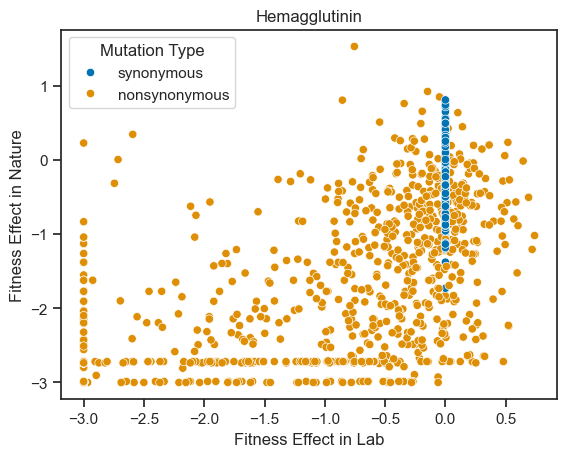

In [7]:
ax = sns.scatterplot(x='dms_effect', y='delta_fitness',data=ha_mut_effects, hue='mut_class')

legend = ax.legend_
legend.set_title("Mutation Type")

plt.title('Hemagglutinin')

ax.set_xlabel('Fitness Effect in Lab')
ax.set_ylabel('Fitness Effect in Nature')


# muts 1550
Pearson R 0.742283929444916


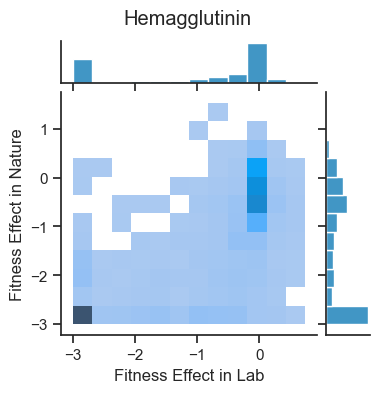

In [8]:
data_to_plot = ha_mut_effects # [ha_mut_effects['mut_class'] == 'nonsynonymous']
print('# muts', len(data_to_plot))
print('Pearson R', data_to_plot['dms_effect'].corr(data_to_plot['delta_fitness']))
sns.jointplot(x='dms_effect', y='delta_fitness', data=data_to_plot, kind='hist', height=4)
sns.despine()

plt.suptitle('Hemagglutinin')
plt.subplots_adjust(top=0.9)
plt.xlabel('Fitness Effect in Lab')
plt.ylabel('Fitness Effect in Nature')
plt.show()

**Observations for scatter plot** 
* syn mutations are around 0
* Most of the mutatuions on the graph are nonsyn = bad for the protein 
* delta fitness mostly ranges from -3 to 0, outlier at 1
* Outlier considered a good mutation, positive delta fitness
* thinking further, protein probably had low functionality due to high number of nonsyn mutations
* Cell entry is the delta fitness metric 0= nuetral, below 0= deleterious cell entry to experiement as delta fitness to nature
* Can compare the two (experiement and nature) to prove the effects of the mutation on the gene of influenza
* Top right fitness in lab neutral, nature is bad.  Opposite in bottom left, middle is all bad
NOTES
A lot of points where mutation is bad in nature but good in the lab
If mutatuions have same effects mutations in top right, most points are above in hyoptheical trend line bad in nature good in lab 
Selection in nature is complex opposite for the lab

**Observation joint plot**
* High density around 0,0
*Lab and nature correlate more 




In [9]:
chart = alt.Chart(ha_mut_effects).mark_rect().encode(
        x=alt.X('codon_site:O', title='site'),
        y=alt.Y('mut_aa:O', title='amino_acid'),
        color=alt.Color(
            'difference_of_columns:Q',
            scale=alt.Scale(
                domain=[-4, 0, 2],
                range=['blue', 'lightgray', 'red']
            )    
        )
    )
chart.title('Hemagglutinin')
chart.plots_adjust(top=0.9)
chart.xlabel('Fitness Effect in Lab')
chart.ylabel('Fitness Effect in Nature')
chart.display()

TypeError: 'UndefinedType' object is not callable

**Observations**
* Looking at this heat map compared to the other heatmap, many of the mutations have a neutral or bad effects on the site.
* The red DOTS Occure very miniscule, but they are still there and prevelant
* This heat map looks over the differences of effects between lab and nature results. 
* The first site is mostly nuetral
* Equation for difference = delta_fitness(fitness in nature) - dms_effect(fitness in the lab), if negative then it would be less in nature than in lab (more fit in a lab), if positve then the opposite would be the same(more fit in nature). 
* Site 138,167, 194, 203, 223, 225,229,246,247, 287,368,and 492 are very variable region, low constraint,attribbute to the finess of the virus influenza
totally white square lacking data
Can be confident that there are differences but due to scatter of data, there is no straight answer.


## NP DATA nucleoprotein

In [89]:
# Read in data
np_dms_data = pd.read_excel('../data/dms_data/Bloom_NP/Supplementary_file_1.xls')

# Rename columns
col_dict = {
    '#SITE' : 'site', 'WT_AA' : 'wt_aa'}
aa_cols = []
for col in np_dms_data.columns:
    if 'PI' in col:
        aa = col[-1]
        col_dict[col] = aa
        aa_cols.append(aa)
np_dms_data.rename(columns=col_dict, inplace=True)

# Melt dataframe
np_dms_data = pd.melt(
    np_dms_data, id_vars=['site', 'wt_aa'], value_vars=aa_cols,
    var_name='mut_aa', value_name='preference'
)

# Make a smaller dataframe that only has data for rows where the wt_aa == mut_aa
wt_data = np_dms_data[np_dms_data['wt_aa'] == np_dms_data['mut_aa']].copy()
wt_data.rename(columns={'preference' : 'wt_preference'}, inplace=True)

# Merge the smaller dataframe with the bigger one
# (not merging wt_aa and mut_aa columns from the smaller dataframe)
np_dms_data = np_dms_data.merge(wt_data[['site', 'wt_preference']], on='site')

# Add a column that quantifies the mutation's effect (=preference/wt_preference)
np_dms_data['dms_effect'] = np.log(np_dms_data['preference'] / np_dms_data['wt_preference'])

# Merge DMS data with fitness data from nature
nature_df = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['subtype'] == 'H3N2')
].copy()
nature_df['codon_site'] = nature_df['codon_site'].astype(int)
nature_df.rename(columns= {'codon_site' : 'site'}, inplace=True)
np_dms_data = np_dms_data.merge(nature_df)

np_dms_data['dms_effect'] = np_dms_data['dms_effect'].clip(lower = -3)
np_dms_data['delta_fitness'] = np_dms_data['delta_fitness'].clip(lower = -3)
np_dms_data["difference_of_columns"] = np_dms_data['delta_fitness']- np_dms_data['dms_effect']

np_dms_data.head()
np_dms_data[np_dms_data['site'] == 425]

,site,wt_aa,mut_aa,preference,wt_preference,dms_effect,subtype,segment,gene,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound,difference_of_columns
530,425,I,I,0.224527,0.224527,0.000000,H3N2,NP,NP,synonymous,136,3.894864,2.614519,69.835561,0.398578,182.586425,6.983556,0.398578
1232,425,I,T,0.107160,0.224527,-0.739673,H3N2,NP,NP,nonsynonymous,0,0.100000,1.441764,34.917781,-2.668452,50.343187,3.491778,-1.928779
1338,425,I,V,0.212105,0.224527,-0.056915,H3N2,NP,NP,nonsynonymous,3,0.100000,1.446053,34.461230,-2.671423,49.832748,3.446123,-2.614508


<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

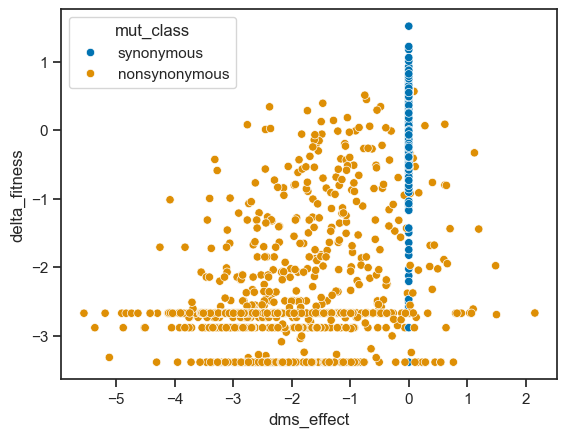

In [69]:
sns.scatterplot(x='dms_effect', y='delta_fitness',data=np_dms_data, hue='mut_class')


**Observations**
* NP Nucleoprotein- Most of the data points lie below the linear regression
* Syn- neutral in the lab and in nature (DMS experiement syn mutations are defined to have an effect of 0)
* Non syn- as the dms get more - the fitness in the nature (selecting proteins)
* Lab is attempting to show effects in nature (selecting for the proteins function able in the lab)
*In nature similating its ability to grow in nature the results are similar

# muts 1389
Pearson R 0.6855118651235117


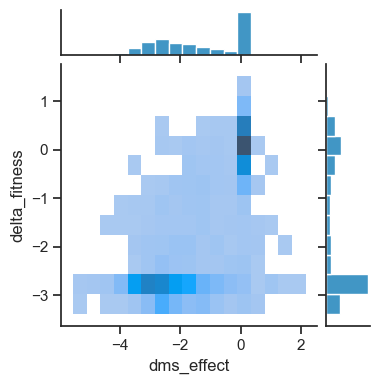

In [71]:
data_to_plot = np_dms_data #['mut_class'] == 'nonsynonymous']
print('# muts', len(data_to_plot))
print('Pearson R', data_to_plot['dms_effect'].corr(data_to_plot['delta_fitness']))
sns.jointplot(x='dms_effect', y='delta_fitness', data=data_to_plot, kind='hist', height=4)
sns.despine()
plt.show()

In [80]:
chart = alt.Chart(np_dms_data).mark_rect().encode(
        x=alt.X('site:O', title='site'),
        y=alt.Y('mut_aa:O', title='amino_acid'),
        color=alt.Color(
            'difference_of_columns:Q',
            scale=alt.Scale(
                domain=[-4, 0, 2],
                range=['blue', 'lightgray', 'red']
            )    
        )
    )
chart.display()

alt.Chart(...)

**Observations**
* Patch of blue in region 424-429 also 442, 454-455, 49-50, and 493, 472-273
* V and T, high preference to 424-429
* What 


In [ ]:
np_dms_data[np_dms_data['site'].between(424, 428)].sort_values('site')


,site,wt_aa,mut_aa,preference,wt_preference,dms_effect,subtype,segment,gene,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound,difference_of_columns
66,424,T,A,0.091210,0.150105,-0.498171,H3N2,NP,NP,nonsynonymous,1,0.100000,1.446053,35.353610,-2.671423,51.123176,3.535361,-2.173252
529,424,T,I,0.022626,0.150105,-1.892231,H3N2,NP,NP,nonsynonymous,35,0.965019,1.786959,36.268717,-0.616123,64.810720,3.626872,1.276108
1231,424,T,T,0.150105,0.150105,0.000000,H3N2,NP,NP,synonymous,71,2.117819,2.726776,105.559492,-0.252733,287.837065,10.555949,-0.252733
530,425,I,I,0.224527,0.224527,0.000000,H3N2,NP,NP,synonymous,136,3.894864,2.614519,69.835561,0.398578,182.586425,6.983556,0.398578
1232,425,I,T,0.107160,0.224527,-0.739673,H3N2,NP,NP,nonsynonymous,0,0.100000,1.441764,34.917781,-2.668452,50.343187,3.491778,-1.928779
1338,425,I,V,0.212105,0.224527,-0.056915,H3N2,NP,NP,nonsynonymous,3,0.100000,1.446053,34.461230,-2.671423,49.832748,3.446123,-2.614508
531,426,M,I,0.127772,0.089358,0.357591,H3N2,NP,NP,nonsynonymous,13,0.495801,3.624405,111.561497,-1.989271,404.344035,11.156150,-2.346862
1233,426,M,T,0.096378,0.089358,0.075625,H3N2,NP,NP,nonsynonymous,0,0.100000,1.441764,37.187166,-2.668452,53.615104,3.718717,-2.744077
1339,426,M,V,0.123480,0.089358,0.323423,H3N2,NP,NP,nonsynonymous,0,0.100000,1.446053,35.929813,-2.671423,51.956396,3.592981,-2.994845
67,427,A,A,0.079232,0.079232,0.000000,H3N2,NP,NP,synonymous,55,1.494505,1.860076,110.404412,-0.218822,205.360563,11.040441,-0.218822


## PB2 Protein DMS Dataframe

In [133]:

pb2_dms_data = pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
#Rename columns
col_dict = {
    'log2effectA549' : 'dms_effect', 
    'wildtype' : 'wt_aa', 
    'mutation' : 'mut_aa'
    }
pb2_dms_data.rename(columns=col_dict, inplace=True)
pb2_dms_data.head()

# Merge pb2_dms_data with nature fitness_df
data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['subtype'] == 'H3N2')
]
data['site'] = data['site'].astype(int)
pb2_dms_data = (pb2_dms_data.merge(data, on=['site', 'wt_aa', 'mut_aa'], how='inner'))

pb2_dms_data['dms_effect'] = pb2_dms_data['dms_effect'].clip(lower = -3)
pb2_dms_data['delta_fitness'] = pb2_dms_data['delta_fitness'].clip(lower = -3)
pb2_dms_data["difference_of_columns"] = pb2_dms_data['delta_fitness']- pb2_dms_data['dms_effect']

pb2_dms_data.head()

/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_35640/3579851920.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['site'] = data['site'].astype(int)


,site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,...,gene,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound,difference_of_columns
0,16,T,A,0.048321,0.043724,-4.371203,-4.515428,0.306659,0.521852,-1.705293,...,PB2,nonsynonymous,1,0.200000,2.892105,40.218956,-2.671423,116.317444,4.021896,-0.966130
1,21,T,A,0.036946,0.034397,-4.758455,-4.861560,0.404254,0.614440,-1.306667,...,PB2,nonsynonymous,29,0.802358,1.446053,36.143484,-0.589038,52.265376,3.614348,0.717629
2,23,T,A,0.034440,0.016598,-4.859786,-5.912840,0.189128,0.086402,-2.402566,...,PB2,nonsynonymous,0,0.100000,1.446053,39.128126,-2.671423,56.581326,3.912813,-0.268857
3,24,T,A,0.070102,0.060182,-3.834407,-4.054523,0.482933,0.302529,-1.050106,...,PB2,nonsynonymous,1,0.100000,1.446053,38.444493,-2.671423,55.592756,3.844449,-1.621316
4,25,V,A,0.055386,0.027934,-4.174339,-5.161844,0.405572,0.125474,-1.301969,...,PB2,nonsynonymous,0,0.100000,1.441764,40.053532,-2.668452,57.747727,4.005353,-1.366484


In [119]:
pb2_dms_data.head()

,site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,log2effectCCL141,mutdiffsel,Known human adaptive,Experimentally adaptive in
0,1,M,A,0.018441,0.035779,-5.760954,-4.804750,0.037634,0.098789,-4.731825,-3.339500,-0.596582,No,NaN
1,2,E,A,0.017338,0.030416,-5.849903,-5.039008,0.093657,0.195126,-3.416476,-2.357521,-0.642891,No,NaN
2,3,R,A,0.029029,0.022867,-5.106354,-5.450617,0.172319,0.077507,-2.536850,-3.689531,0.629427,No,NaN
3,4,I,A,0.033297,0.049470,-4.908455,-4.337306,0.269836,0.486289,-1.889844,-1.040116,-0.681969,No,NaN
4,5,K,A,0.062883,0.041191,-3.991193,-4.601543,0.766084,0.390159,-0.384426,-1.357867,0.610305,No,NaN


In [134]:
fitness_df.head()
col_dict = ({'codon_site' : 'site'})

fitness_df.rename(columns=col_dict, inplace=True)

fitness_df.head()

,subtype,segment,gene,site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1N1,HA,HA,507,S,L,nonsynonymous,19,0.301239,1.786959,63.072941,-1.780368,112.708778,6.307294
1,H1N1,HA,HA,507,S,P,nonsynonymous,0,0.100000,1.441764,62.737059,-2.668452,90.452011,6.273706
2,H1N1,HA,HA,507,S,S,synonymous,67,1.063194,1.860076,189.052941,-0.559339,351.652781,18.905294
3,H1N1,HA,HA,508,E,E,synonymous,139,2.233818,2.956514,62.225294,-0.280299,183.969978,6.222529
4,H1N1,HA,HA,508,E,G,nonsynonymous,24,0.385695,1.446053,62.225294,-1.321545,89.981043,6.222529


<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

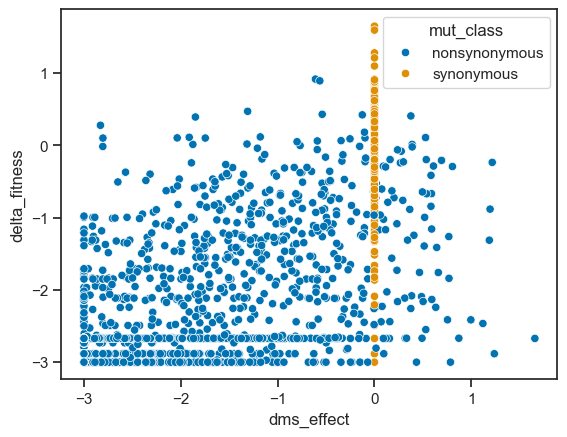

In [135]:
# Scatter plot of pb2
sns.scatterplot(x='dms_effect', y='delta_fitness',data=pb2_dms_data, hue='mut_class')


# muts 2136
Pearson R 0.7612299088371792


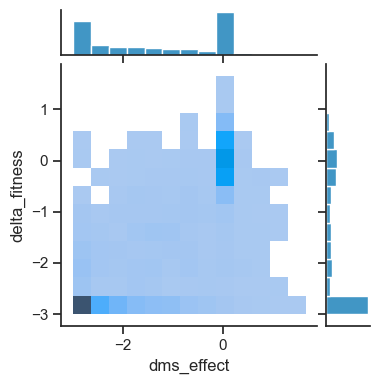

In [136]:
# Joint plot for Pb2 Protein
data_to_plot = pb2_dms_data #['mut_class'] == 'nonsynonymous']
print('# muts', len(data_to_plot))
print('Pearson R', data_to_plot['dms_effect'].corr(data_to_plot['delta_fitness']))
sns.jointplot(x='dms_effect', y='delta_fitness', data=data_to_plot, kind='hist', height=4)
sns.despine()
plt.show()

In [137]:
#Heat map for Pb2 Protein
chart = alt.Chart(pb2_dms_data).mark_rect().encode(
        x=alt.X('site:O', title='site'),
        y=alt.Y('mut_aa:O', title='amino_acid'),
        color=alt.Color(
            'difference_of_columns:Q',
            scale=alt.Scale(
                domain=[-4, 0, 2],
                range=['blue', 'lightgray', 'red']
            )    
        )
    )
chart.display()

alt.Chart(...)

**Observations**
* A lot of blue sites around 69 (H and K bad for protein) and 143-173
* Towards the end, many red, showing high affinity for mutations
* Pb2 is similar to NP


## NA Protein Neuraminidase DATA

In [ ]:
na_dms_data = pd.read_excel('../data/dms_data/Wang_NA/msystems.00670-23-s0006.xlsx')

# Extract the site number
na_dms_data['site'] = na_dms_data['AA change'].apply(lambda x: int(x[1:-1]))

# Extract wt_aa and mut_aa
na_dms_data['wt_aa'] = na_dms_data['AA change'].apply(lambda x: x[0])
na_dms_data['mut_aa'] = na_dms_data['AA change'].apply(lambda x: x[-1])

# Compute DMS effect
na_dms_data['dms_effect'] = np.log(na_dms_data[['RF_CTRL_Rep1', 'RF_CTRL_Rep2', 'RF_CTRL_Rep3']].mean(axis=1))

# Merge DMS data and fitness data from nature
data = fitness_df[
    (fitness_df['gene'] == 'NA') &
    (fitness_df['subtype'] == 'H1N1')
]
data['site'] = data['site'].astype(int)
na_dms_data = (na_dms_data.merge(data, on=['site', 'wt_aa', 'mut_aa'], how='inner'))

# Difference of Columns
na_dms_data['dms_effect'] = na_dms_data['dms_effect'].clip(lower = -3)
na_dms_data['delta_fitness'] = na_dms_data['delta_fitness'].clip(lower = -3)
na_dms_data["difference_of_columns"] = na_dms_data['delta_fitness']- _dms_data['dms_effect']


na_dms_data.head()

/Users/cbenton/miniforge3/envs/flu-syn-rates/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_35640/996471586.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['site'] = data['site'].astype(int)


,NT Pos,NT change,AA change,RF_CTRL_Rep1,RF_CTRL_Rep2,RF_CTRL_Rep3,RF_OS_Rep1,RF_OS_Rep2,RF_OS_Rep3,RF_ZA_Rep1,...,gene,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound,difference_of_columns
0,29,A29G,I7M,0.236588,0.273200,0.180735,0.123353,0.090473,0.127528,0.155207,...,NA,nonsynonymous,4,0.100000,1.446053,56.034776,-2.671423,81.029230,5.603478,-1.202506
1,30,A30G,I8V,0.787755,0.122940,0.195716,0.079478,0.024983,0.459100,0.068573,...,NA,nonsynonymous,13,0.232066,1.446053,56.018453,-1.829569,81.005625,5.601845,-0.832079
2,31,T31C,I8T,1.024614,0.520558,0.415059,1.035161,1.085222,0.299863,0.947599,...,NA,nonsynonymous,37,0.660246,1.441764,56.039744,-0.781010,80.796066,5.603974,-0.355460
3,32,A32G,I8M,0.353603,0.248879,0.558698,0.505670,0.053622,0.335927,0.089944,...,NA,nonsynonymous,22,0.393416,1.446053,55.920511,-1.301726,80.863996,5.592051,-0.352551
4,33,A33G,T9A,0.919856,1.349883,0.792259,0.519561,0.029313,0.808016,0.274902,...,NA,nonsynonymous,41,0.735723,1.446053,55.727466,-0.675739,80.584843,5.572747,-0.696194


In [229]:
# Step 1: Filter the fitness data for NA gene and H1N1 subtype
filtered_fitness = fitness_df[
    (fitness_df['gene'] == 'NA') &
    (fitness_df['subtype'] == 'H1N1')
].copy()

# Step 2: Check column names to identify the correct 'site' column
print("Fitness column names:", fitness_df.columns)



# Step 3: Check overlap of merge keys (optional but helpful debug)
print("Fitness data rows:", len(filtered_fitness))
print("DMS data rows:", len(na_dms_data))



# Step 4: Merge datasets
data['site'] = data['site'].astype(int)
merged_data = na_dms_data.merge(
    filtered_fitness,
    on=['site', 'wt_aa', 'mut_aa'],
    how='inner',
    suffixes=('', '_fitness')
)



# Step 7: Plot the scatterplot
sns.scatterplot(
    data=merged_data,
    x='dms_effect',
    y='delta_fitness',
    hue='mut_class'
)
plt.xlabel('Fitness Effect in Nature')
plt.ylabel('Fitness Effect in Lab')
plt.legend(title='Mutation Type')
plt.title('NA Protein: Lab vs Nature Mutation Effects')
plt.show()






Fitness column names: Index(['subtype', 'segment', 'gene', 'codon_site', 'wt_aa', 'mut_aa',
       'mut_class', 'actual_count', 'rate', 'mean_syn_rate', 'evo_opp',
       'delta_fitness', 'expected_count', 'expected_count_lower_bound'],
      dtype='object')
Fitness data rows: 1464
DMS data rows: 198


KeyError: 'site'

<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

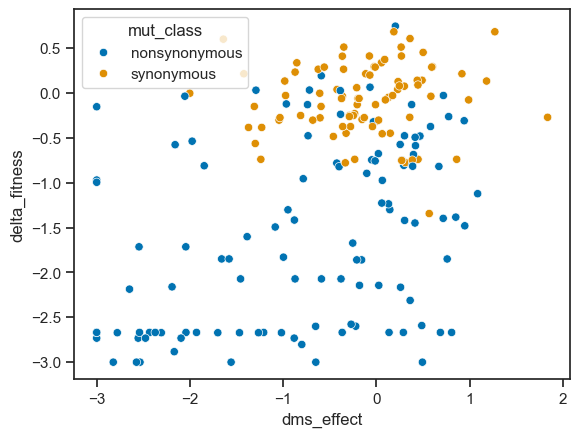

In [ ]:
# Scatter plot of na
sns.scatterplot(x='dms_effect', y='delta_fitness',data=na_dms_data, hue='mut_class')

# muts 198
Pearson R 0.4448926992483659


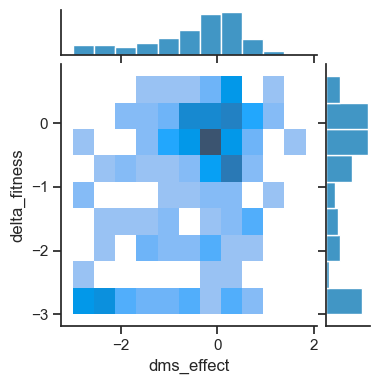

In [171]:
# Joint plot for NA
data_to_plot = na_dms_data #['mut_class'] == 'nonsynonymous']
print('# muts', len(data_to_plot))
print('Pearson R', data_to_plot['dms_effect'].corr(data_to_plot['delta_fitness']))
sns.jointplot(x='dms_effect', y='delta_fitness', data=data_to_plot, kind='hist', height=4)
sns.despine()
plt.show()

In [172]:
#Heatmap for NA Protein
chart = alt.Chart(na_dms_data).mark_rect().encode(
        x=alt.X('site:O', title='site'),
        y=alt.Y('mut_aa:O', title='amino_acid'),
        color=alt.Color(
            'difference_of_columns:Q',
            scale=alt.Scale(
                domain=[-4, 0, 2],
                range=['blue', 'lightgray', 'red']
            )    
        )
    )
chart.display()

alt.Chart(...)

**Observations**
* There are very few mutations concerning this protein, and many of the mutations for the protein have a negative effect
* Sites 7-67 contain many negative/ deleterious mutations
* Many of the mutations are bad in both nature and lab (looking at obeservations from the joint plot)

## Results on Proteins HA, NP, PB2, and NA


# DATA ON ALL PROTEINS

Analyze the distribution of fitness effects for syn, nonsyn, and nonsense mutations. Do this for H3N2.

In [ ]:
data = fitness_df[fitness_df['subtype']== 'H3N2'] 



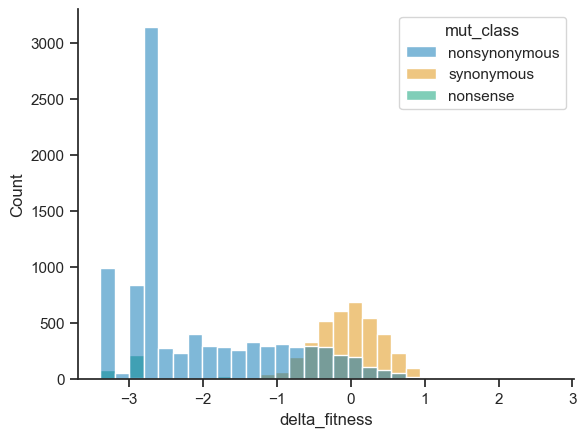

In [ ]:
sns.histplot(x= 'delta_fitness', data=data, hue='mut_class')
sns.despine()
plt.show()

In [ ]:
fitness_df[fitness_df['subtype']== 'H3N2']

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
13310,H3N2,HA,HA,1,M,I,nonsynonymous,22,0.369028,3.624405,234.176471,-2.284573,848.750341,23.417647
13311,H3N2,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.441764,78.063529,-2.668452,112.549159,7.806353
13312,H3N2,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.446053,78.063529,-2.671423,112.883963,7.806353
13313,H3N2,HA,HA,2,K,E,nonsynonymous,25,0.324375,1.446053,77.071176,-1.494691,111.448969,7.707118
13314,H3N2,HA,HA,2,K,K,synonymous,134,4.003485,5.913029,77.076471,-0.389993,455.755391,7.707647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26809,H3N2,PB2,PB2,759,N,D,nonsynonymous,2,0.100000,1.446053,40.169373,-2.671423,58.087022,4.016937
26810,H3N2,PB2,PB2,759,N,N,synonymous,9,0.224159,1.441764,40.150066,-1.861267,57.886905,4.015007
26811,H3N2,PB2,PB2,759,N,S,nonsynonymous,1,0.100000,1.446053,40.183853,-2.671423,58.107961,4.018385
26812,H3N2,PB2,PB2,760,*,*,synonymous,181,4.683018,2.892105,77.300570,0.481958,223.561369,7.730057


<Axes: xlabel='gene', ylabel='delta_fitness'>

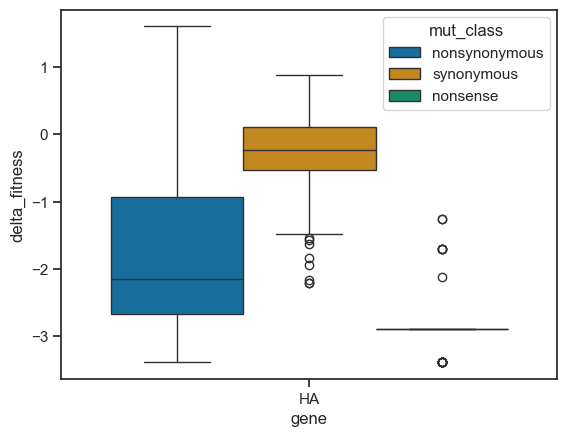

In [222]:
sns.boxplot(x= 'gene', y= 'delta_fitness', hue= 'mut_class', data=data)

**Observations**
* Non syn mutations for all segments tend to stay in the range of -1 or below
* Syn mutations for all the segments tend to stay in the range of 0 to 0.3
* Nonsense mutations for all the segments tend to stay in the range of -3 or below
* For the segment NS--highest number of nonsyn mutations
* For segment PA--highest number of nonsense mutations
* All genes appear to be under high constraint
* Genes appear to be very important for fitness of influenza, essential not accessory?


### plot distribution of fitness effects for syn ,non syn, and nonsense mutation


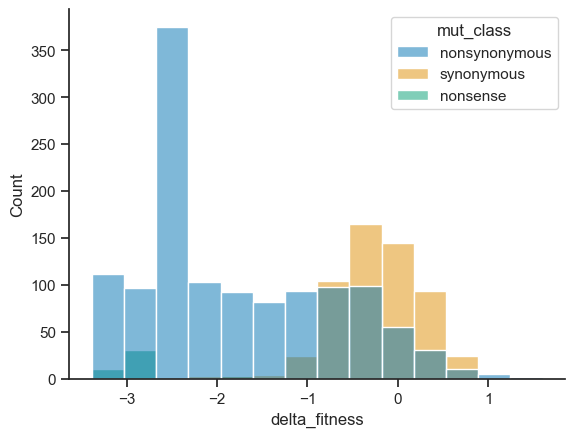

In [ ]:
sns.histplot(x= 'delta_fitness', data=data, hue='mut_class')
sns.despine()
plt.show()


## SUBTYPE ANALYSIS

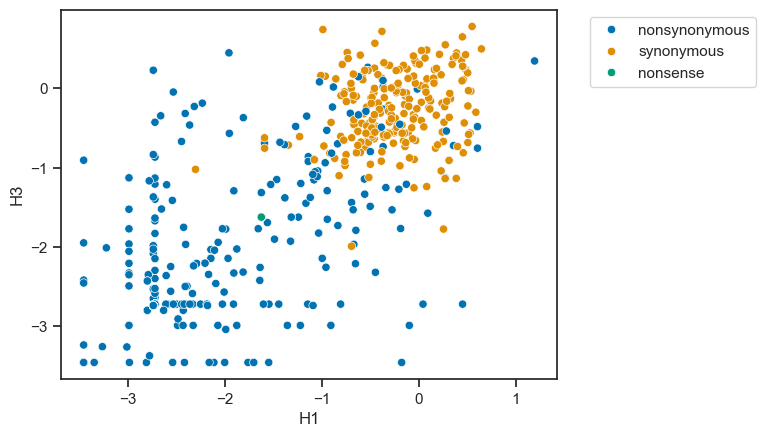

In [233]:
# Read in HA data fitness data
ha_fitness = pd.read_csv('../results/ha_fitness.csv')
ha_fitness.head()
# Scatter plot of H1 vs H3
sns.scatterplot(x='H1', y='H3', data=ha_fitness, hue='mut_class')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

**Observations**
* Most similar in both subtypes but there are differences -epistatis (Top left and bottom right)
* Epistatis : change one thing at a time, whether that one thing is acceptable depends on enviornment, proteins mutations have effects sometimes bad or good, effect depends on enviornment.
* Sequence identity HA less than 50 percent identical 

# muts 1512
Pearson R 0.8553769984373163


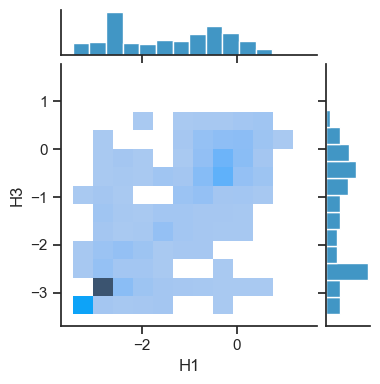

In [ ]:
# Joint plot for H1 vs H3
sns.jointplot(x='H1', y='H3', data=ha_fitness, kind='hist', height=4)
print('# muts', len(ha_fitness))
print('Pearson R', ha_fitness['H1'].corr(ha_fitness['H3']))
sns.despine()
plt.show()

**Observations**
* Different in over half the sites for H1 and H3 but effects are similar
* WHY is that? this structures are similar

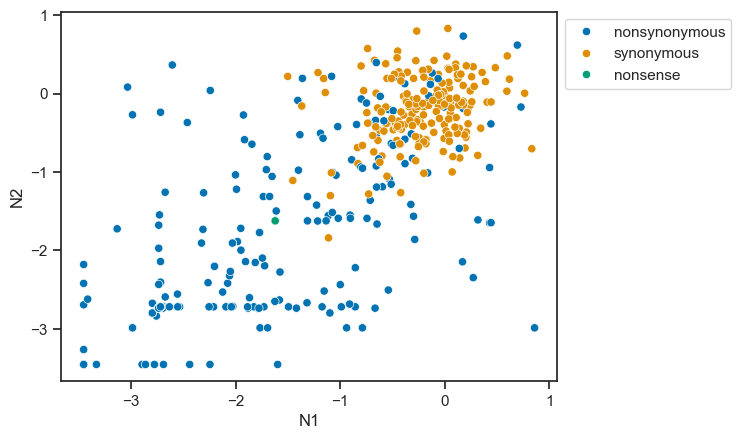

In [237]:
# read in NA subtype analysis
na_fitness = pd.read_csv('../results/na_fitness.csv')
na_fitness.head()
# Scatter plot of N1 vs N2
sns.scatterplot(x='N1', y='N2', data=na_fitness, hue='mut_class')
plt.legend(bbox_to_anchor=(1, 1))



# muts 2768
Pearson R 0.8767971979932667


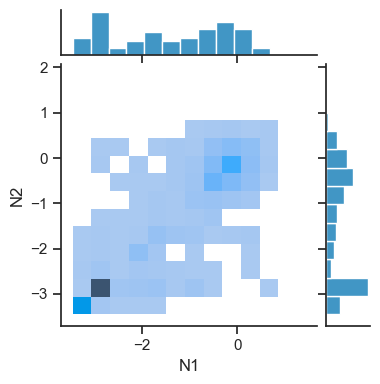

In [ ]:
# Joint plot for N1 vs N2
sns.jointplot(x='N1', y='N2', data=na_fitness, kind='hist', height=4)
print('# muts', len(na_fitness))
print('Pearson R', na_fitness['N1'].corr(na_fitness['N2']))
sns.despine()
plt.show()


**Observations**
* Similar to HA
* Syn mutations are neautral for both subtypes
* Non syn mutations, majority look deleterious
* Nonsense mutations are deleterious for both 
* Some mutations for both subtypes have positive effects top left corner and bottom right corner

/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/585097903.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/585097903.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Mutation Type')


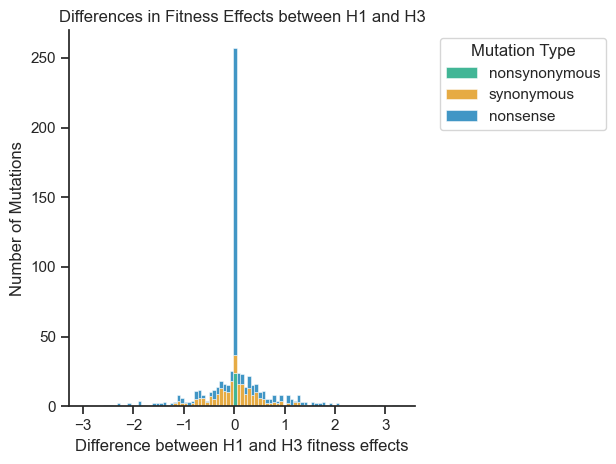

<Figure size 640x480 with 0 Axes>

In [42]:


# Make a tradtional histogram using this data and keep the same colors of the mut_class
difference_plot = ha_fitness.assign(
    difference = ha_fitness['H1'] - ha_fitness['H3']
)
sns.histplot(x='difference', data=difference_plot, hue='mut_class', multiple='stack')
plt.xlabel('Difference between H1 and H3 fitness effects')
plt.ylabel('Number of Mutations')
plt.title('Differences in Fitness Effects between H1 and H3')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# legend is not showing up, so add it please
plt.legend(title='Mutation Type')
# Put the colors of the legend in the same order as the mut_class
plt.legend(
    title='Mutation Type',
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    labels=['nonsynonymous', 'synonymous', 'nonsense']
)
plt.tight_layout()
sns.despine()
plt.show()
sns.despine()

plt.show()


**Observations**
* Most synonymous mutations have similar effects on both H3 and H1
* majority of nonsyn mutations had similar effects on both H3 and H1
* Nonsense mutations had similar mutations on both H3 and H1

/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/1150122555.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/1150122555.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Mutation Type')


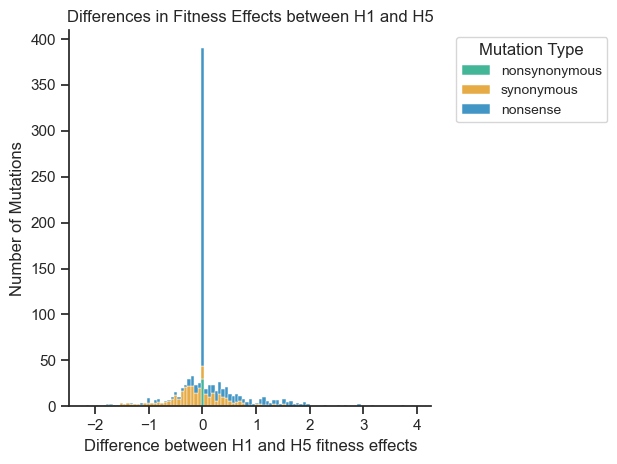

In [ ]:
# Make a traditional Histogram of fitness effects for H1 and H5 using the same data and keep the same colors of the mut_class
# This will show the difference between H1 and H5 fitness effects
ha_fitness = pd.read_csv('../results/ha_fitness.csv')

difference_plot =  ha_fitness.assign(
    difference = ha_fitness['H1'] - ha_fitness['H5']
)
sns.histplot(x='difference', data=difference_plot, hue='mut_class', multiple='stack')
plt.xlabel('Difference between H1 and H5 fitness effects')
plt.ylabel('Number of Mutations')
plt.title('Differences in Fitness Effects between H1 and H5')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(title='Mutation Type')
plt.legend(
    title='Mutation Type',
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    labels=['nonsynonymous', 'synonymous', 'nonsense']
)

# Make the legend very small
plt.legend(
    title='Mutation Type',
    loc='upper left',   
    bbox_to_anchor=(1.05, 1),
    labels=['nonsynonymous', 'synonymous', 'nonsense'],
    fontsize='small'
)

plt.tight_layout()
sns.despine()
plt.show()


/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/1130879938.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
/var/folders/5d/3zd7_jjj77zdxm728kpc92d80000gq/T/ipykernel_8960/1130879938.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Mutation Type')


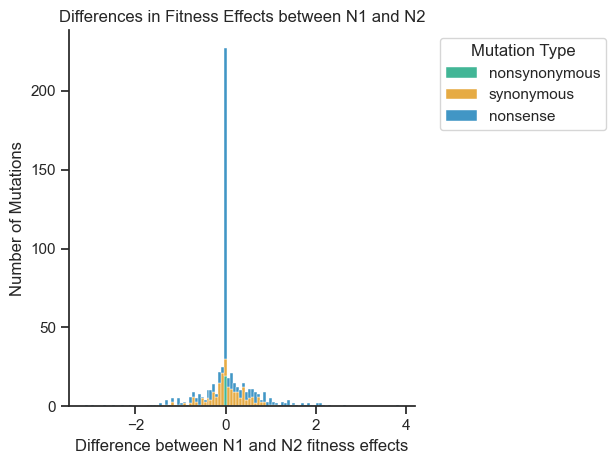

In [39]:
# Histogram comparing differences between N1 and N2
na_fitness = pd.read_csv('../results/na_fitness.csv')

difference_plot = na_fitness.assign(
    difference = na_fitness['N1'] - na_fitness['N2']
)
sns.histplot(x='difference', data=difference_plot, hue='mut_class', multiple='stack')
plt.xlabel('Difference between N1 and N2 fitness effects')
plt.ylabel('Number of Mutations')
plt.title('Differences in Fitness Effects between N1 and N2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(title='Mutation Type')
plt.legend(
    title='Mutation Type',
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    labels=['nonsynonymous', 'synonymous', 'nonsense']
)
plt.tight_layout()
sns.despine()
plt.show()

## Entrenchment Observations

In [13]:
numbering_df = pd.read_csv('../results/alignment_numbering.csv')
numbering_df.head()

,subtype,segment,gene,alignment_index,codon_site,wt_aa
0,H1,HA,HA,1,1,M
1,H1,HA,HA,2,2,K
2,H1,HA,HA,3,3,A
3,H1,HA,HA,4,4,N
4,H1,HA,HA,5,5,L


In [ ]:
# Slice the above dataframe to just include rows for the H1 subtype
h1_data = numbering_df[numbering_df['subtype'] == 'H1'].copy()

# Change the column name from wt_aa to h1_aa
col_dict = {'wt_aa': 'h1_aa'}
h1_data.rename(columns=col_dict, inplace=True)

# Do the same thing for H3, then merge the two dataframes on the alignment_index
# column
h3_data = numbering_df[numbering_df['subtype'] == 'H3'].copy()
col_dict = {'wt_aa': 'h3_aa'}
h3_data.rename(columns=col_dict, inplace=True)
# Merging h1 and h3 df
cols_to_keep = ['alignment_index', 'h1_aa', 'h3_aa']
h1h3_data = pd.merge(
    h1_data[['alignment_index', 'h1_aa']], h3_data[['alignment_index', 'h3_aa']],
    on='alignment_index', how='inner'
)

# Make a new column that gives the mutation string from H1 to H3
h1h3_data['forward_mut'] = h1h3_data['h1_aa'] + h1h3_data['alignment_index'].astype(str) + h1h3_data['h3_aa']

# Also make a column that gives the mutation string from H3 to H1, calling it 'reverse_mut'
h1h3_data['reverse_mut'] = h1h3_data['h3_aa'] + h1h3_data['alignment_index'].astype(str) + h1h3_data['h1_aa']

# Subset the dataframe to only include rows where the h1_aa and h3_aa are not the same
h1h3_data = h1h3_data[h1h3_data['h1_aa'] != h1h3_data['h3_aa']].copy()  

# Get the fitness data for H1, merge with numbering_df on all the columns except alignment_index
# and subset to the forward mutations. Then, change the delta_fitness column to be the fitness effect of the forward mutation
# like "forward_effect"

# Get the fitness data for H3, merging with numbering_df as above, and subset to the reverse mutations. Then,
# change the delta_fitness column to be the fitness effect of the reverse mutation
# like "reverse_effect"

# Then, merge these dataframes on "alignment_index"

# Then, make a scatter of forward_effect vs reverse_effect

h1h3_data.head()

,alignment_index,h1_aa,h3_aa,forward_mut,reverse_mut
2,3,A,T,A3T,T3A
3,4,N,I,N4I,I4N
4,5,L,I,L5I,I5L
5,6,L,A,L6A,A6L
6,7,V,L,V7L,L7V


In [ ]:
# Get the fitness data for H1
h1_fitness = fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H1')
].copy()
h1_fitness['codon_site'] = h1_fitness['codon_site'].astype(int)

# Merge with numbering_df to add the alignment_index column
h1_fitness = h1_fitness.merge(numbering_df, how='inner')

# Subset to the forward mutations

# h1_fitness = h1_fitness.merge(
    # numbering_df[['codon_site', 'wt_aa']],
    # on=['codon_site', 'wt_aa'],
    # how='inner'
# )
# h1_fitness = h1_fitness[h1_fitness['mut_class'] == 'forward']

# Then, change the delta_fitness column to be the fitness effect of the forward mutation like "forward_effect"
# h1_fitness = h1_fitness.rename(columns={'delta_fitness': 'forward_effect'})

h1_fitness.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1,HA,HA,1,M,I,nonsynonymous,0,0.300000,3.866466,218.677059,-2.556314,845.507457,21.867706
1,H1,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.542108,74.986471,-2.735735,115.637218,7.498647
2,H1,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.515710,74.986471,-2.718469,113.657736,7.498647
3,H1,HA,HA,2,K,E,nonsynonymous,88,1.258105,1.515710,69.946471,-0.186277,106.018559,6.994647
4,H1,HA,HA,2,K,K,synonymous,122,1.754950,3.160456,69.517647,-0.588276,219.707444,6.951765


In [63]:
numbering_df.head()

,subtype,segment,gene,alignment_index,codon_site,wt_aa
0,H1,HA,HA,1,1,M
1,H1,HA,HA,2,2,K
2,H1,HA,HA,3,3,A
3,H1,HA,HA,4,4,N
4,H1,HA,HA,5,5,L


In [65]:
h1_fitness = h1_fitness.merge(numbering_df, how='inner')
h1_fitness.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound,alignment_index
0,H1,HA,HA,1,M,I,nonsynonymous,0,0.300000,3.866466,218.677059,-2.556314,845.507457,21.867706,1
1,H1,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.542108,74.986471,-2.735735,115.637218,7.498647,1
2,H1,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.515710,74.986471,-2.718469,113.657736,7.498647,1
3,H1,HA,HA,2,K,E,nonsynonymous,88,1.258105,1.515710,69.946471,-0.186277,106.018559,6.994647,2
4,H1,HA,HA,2,K,K,synonymous,122,1.754950,3.160456,69.517647,-0.588276,219.707444,6.951765,2


In [44]:
# Get the fitness data for H1, merge with numbering_df on all the columns except alignment_index and subset to the forward mutations. Then, change the delta_fitness column to be the fitness effect of the forward mutation like "forward_effect"
h1_fitness = fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H1N1')
].copy()
h1_fitness['codon_site'] = h1_fitness['codon_site'].astype(int)
h1_fitness = h1_fitness.merge(
    numbering_df[['codon_site', 'wt_aa']],
    on=['codon_site', 'wt_aa'],
    how='inner'
)
h1_fitness = h1_fitness[h1_fitness['mutation_type'] == 'forward']
h1_fitness = h1_fitness.rename(columns={'delta_fitness': 'forward_effect'})


# Get the fitness data for H3, merging with numbering_df as above, and subset to the reverse mutations. Then, change the delta_fitness column to be the fitness effect of the reverse mutation like "reverse_effect"
h3_fitness = fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3N2')
].copy()
h3_fitness['codon_site'] = h3_fitness['codon_site'].astype(int)
h3_fitness = h3_fitness.merge(
    numbering_df[['codon_site', 'wt_aa']],
    on=['codon_site', 'wt_aa'],
    how='inner'
)
h3_fitness = h3_fitness[h3_fitness['mutation_type'] == 'reverse']
h3_fitness = h3_fitness.rename(columns={'delta_fitness': 'reverse_effect'})
# Then, merge these dataframes on "alignment_index"
merged_fitness = pd.merge(
    h1_fitness[['alignment_index', 'forward_effect']],
    h3_fitness[['alignment_index', 'reverse_effect']],
    on='alignment_index',
    how='inner'
)

# Then, make a scatter of forward_effect vs reverse_effect
sns.scatterplot(x='forward_effect', y='reverse_effect', data=merged_fitness)
plt.xlabel('Forward Mutation Effect (H1)')
plt.ylabel('Reverse Mutation Effect (H3)')
plt.title('Forward vs Reverse Mutation Effects in HA')
plt.legend(title='Mutation Type')
plt.tight_layout()
sns.despine()
plt.show()

KeyError: 'mutation_type'

In [49]:
h1_fitness.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound


In [11]:
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,mut_class,actual_count,rate,mean_syn_rate,evo_opp,delta_fitness,expected_count,expected_count_lower_bound
0,H1,HA,HA,1,M,I,nonsynonymous,0,0.300000,3.866466,218.677059,-2.556314,845.507457,21.867706
1,H1,HA,HA,1,M,T,nonsynonymous,0,0.100000,1.542108,74.986471,-2.735735,115.637218,7.498647
2,H1,HA,HA,1,M,V,nonsynonymous,0,0.100000,1.515710,74.986471,-2.718469,113.657736,7.498647
3,H1,HA,HA,2,K,E,nonsynonymous,88,1.258105,1.515710,69.946471,-0.186277,106.018559,6.994647
4,H1,HA,HA,2,K,K,synonymous,122,1.754950,3.160456,69.517647,-0.588276,219.707444,6.951765
